In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap
import warnings

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)

warnings.filterwarnings('ignore')
print('Libraries loaded!')

Libraries loaded!


d:\weddify\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1 - Load Everything
Load data and all 4 trained models.

In [2]:
# Load data
X_train = joblib.load('../data/processed/X_train.pkl')
X_test  = joblib.load('../data/processed/X_test.pkl')
y_train = joblib.load('../data/processed/y_train.pkl')
y_test  = joblib.load('../data/processed/y_test.pkl')

# Load all 4 models
rf_model       = joblib.load('../models/random_forest.pkl')
xgb_model      = joblib.load('../models/xgboost_model.pkl')
cat_model      = joblib.load('../models/catboost_model.pkl')
stacking_model = joblib.load('../models/stacking_ensemble.pkl')

print('Data and all 4 models loaded!')
print('X_test shape:', X_test.shape)

Data and all 4 models loaded!
X_test shape: (2661, 12)


## Step 2 - Full Metrics Comparison
Calculate all metrics for all 4 models on the same test data.

In [3]:
# Evaluate all 4 models
all_results = []

for model, name in [
    (rf_model,       'Random Forest'),
    (xgb_model,      'XGBoost'),
    (cat_model,      'CatBoost'),
    (stacking_model, 'Stacking Ensemble')
]:
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    all_results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'AUC'      : round(roc_auc_score(y_test, y_pred_prob), 4)
    })

results_df = pd.DataFrame(all_results).set_index('Model')
print('=== Final Model Comparison ===')
print(results_df.to_string())

=== Final Model Comparison ===
                   Accuracy  Precision  Recall  F1 Score     AUC
Model                                                           
Random Forest        0.9004     0.9047  0.8944    0.8995  0.9237
XGBoost              0.9000     0.9003  0.8989    0.8996  0.9216
CatBoost             0.9049     0.9049  0.9042    0.9046  0.9211
Stacking Ensemble    0.9068     0.9065  0.9065    0.9065  0.9250


In [4]:
# Show which model is best for each metric
print('=== Best Model per Metric ===')
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']:
    best = results_df[metric].idxmax()
    val  = results_df.loc[best, metric]
    print(f'  {metric:12} : {best} ({val})')

=== Best Model per Metric ===
  Accuracy     : Stacking Ensemble (0.9068)
  Precision    : Stacking Ensemble (0.9065)
  Recall       : Stacking Ensemble (0.9065)
  F1 Score     : Stacking Ensemble (0.9065)
  AUC          : Stacking Ensemble (0.925)


## Step 3 - Confusion Matrices for All 4 Models

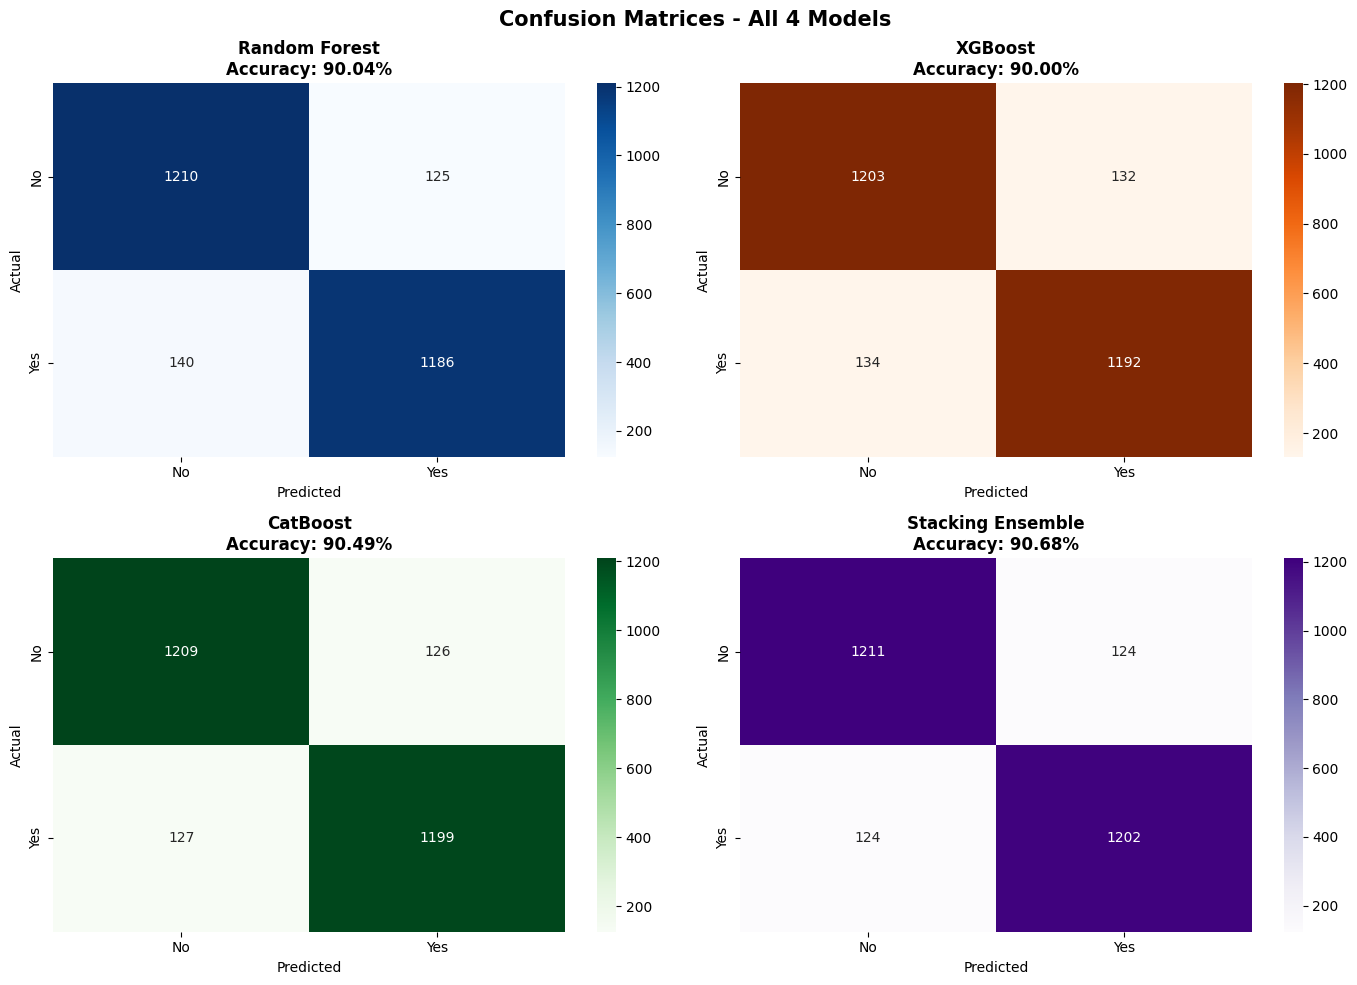

In [5]:
# Plot all 4 confusion matrices in one figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

models_list = [
    (rf_model,       'Random Forest',    'Blues'),
    (xgb_model,      'XGBoost',          'Oranges'),
    (cat_model,      'CatBoost',         'Greens'),
    (stacking_model, 'Stacking Ensemble','Purples')
]

for i, (model, name, cmap) in enumerate(models_list):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[i],
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    acc = accuracy_score(y_test, model.predict(X_test))
    axes[i].set_title(f'{name}\nAccuracy: {acc*100:.2f}%', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrices - All 4 Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/all_confusion_matrices.png')
plt.show()

## Step 4 - ROC Curves for All 4 Models

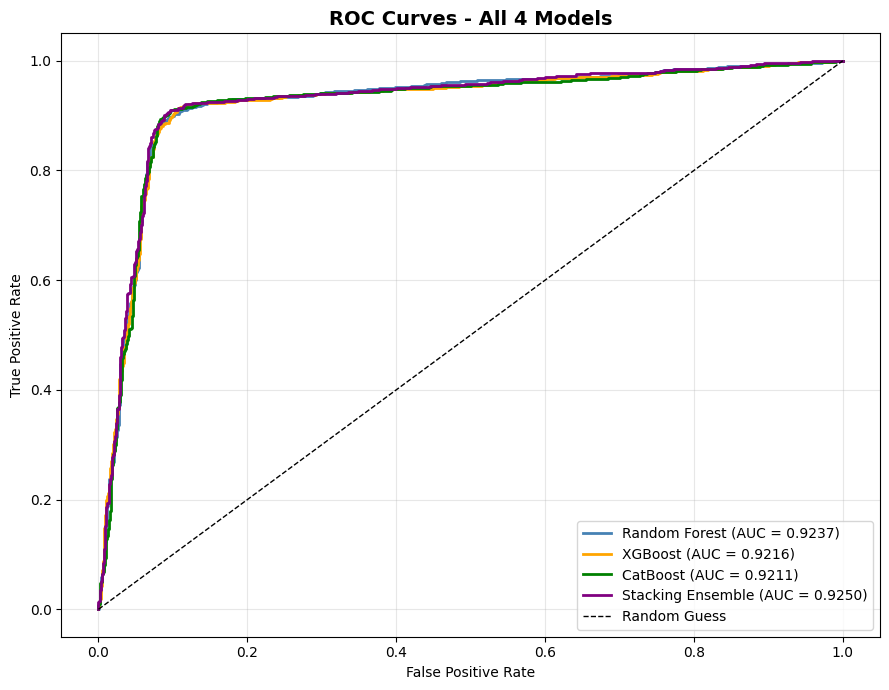

In [6]:
# Plot ROC curves for all 4 models
plt.figure(figsize=(9, 7))

colors = ['steelblue', 'orange', 'green', 'purple']
names  = ['Random Forest', 'XGBoost', 'CatBoost', 'Stacking Ensemble']
models = [rf_model, xgb_model, cat_model, stacking_model]

for model, name, color in zip(models, names, colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})',
             color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1)
plt.title('ROC Curves - All 4 Models', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves_all_models.png')
plt.show()

## Step 5 - Classification Report
Detailed breakdown of precision, recall and F1 for each class.

In [7]:
# Print detailed classification report for best model (Stacking)
print('=== Stacking Ensemble - Detailed Classification Report ===')
print(classification_report(
    y_test,
    stacking_model.predict(X_test),
    target_names=['Not Recommended', 'Recommended']
))

=== Stacking Ensemble - Detailed Classification Report ===
                 precision    recall  f1-score   support

Not Recommended       0.91      0.91      0.91      1335
    Recommended       0.91      0.91      0.91      1326

       accuracy                           0.91      2661
      macro avg       0.91      0.91      0.91      2661
   weighted avg       0.91      0.91      0.91      2661



## Step 6 - SHAP Analysis
SHAP tells us which features are most important for the predictions.
We use CatBoost for SHAP because it has the best native SHAP support.

In [8]:
# SHAP analysis on CatBoost model
print('Running SHAP analysis...')

# Create SHAP explainer
explainer = shap.TreeExplainer(cat_model)

# Calculate SHAP values on test data (use 500 samples for speed)
X_sample    = X_test.iloc[:500]
shap_values = explainer.shap_values(X_sample)

print('SHAP values calculated!')

Running SHAP analysis...
SHAP values calculated!


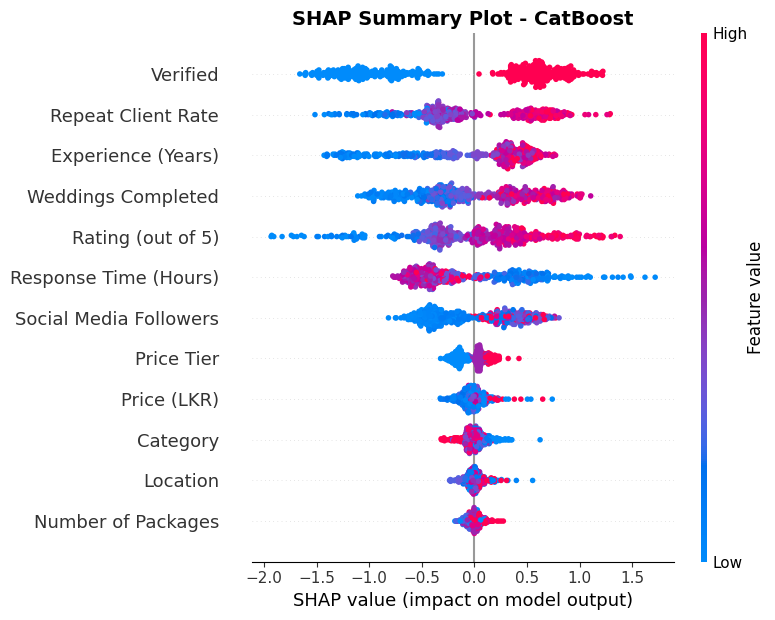

SHAP summary plot saved!


In [9]:
# SHAP Summary Plot - shows all features and their impact
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_test.columns.tolist(),
    show=False
)
plt.title('SHAP Summary Plot - CatBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary_plot.png', bbox_inches='tight')
plt.show()
print('SHAP summary plot saved!')

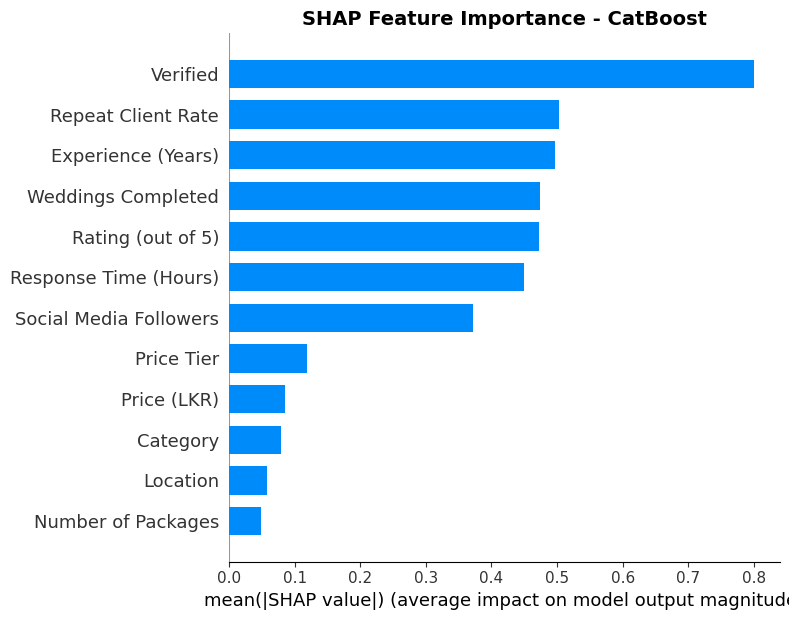

In [10]:
# SHAP Bar Plot - average importance of each feature
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=X_test.columns.tolist(),
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance - CatBoost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_feature_importance.png', bbox_inches='tight')
plt.show()

## Step 7 - Save Final Results Table

In [11]:
# Save final comparison table
results_df.to_csv('../outputs/results/final_model_comparison.csv')
print('Final results table saved!')

# Print final summary
print('\n=== FINAL SUMMARY ===')
print(results_df[['Accuracy', 'F1 Score', 'AUC']].to_string())

best_model = results_df['AUC'].idxmax()
print(f'\nBest Model : {best_model}')
print(f'Accuracy   : {results_df.loc[best_model, "Accuracy"]*100:.2f}%')
print(f'F1 Score   : {results_df.loc[best_model, "F1 Score"]}')
print(f'AUC        : {results_df.loc[best_model, "AUC"]}')

Final results table saved!

=== FINAL SUMMARY ===
                   Accuracy  F1 Score     AUC
Model                                        
Random Forest        0.9004    0.8995  0.9237
XGBoost              0.9000    0.8996  0.9216
CatBoost             0.9049    0.9046  0.9211
Stacking Ensemble    0.9068    0.9065  0.9250

Best Model : Stacking Ensemble
Accuracy   : 90.68%
F1 Score   : 0.9065
AUC        : 0.925
